# Loading Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# **A. Data Cleaning**

## **Dropping Irrelevant Columns**

In [3]:
df.drop(['id'], axis=1, inplace =True)

## **Handling Missing Values**

In [4]:
# Checking for missing values
df.isnull().sum().sort_values(ascending = False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64

In [5]:
# Impute missing numerical values with the median
num_imputer = SimpleImputer(strategy='median')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [6]:
# Impute missing categorical values with the most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [7]:
# Feature Scaling
scaler = StandardScaler()
scaled_cols = numerical_cols.drop('num', errors='ignore')  # Exclude target variable if present
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])W

In [8]:
#Preparing Target Variable
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [9]:
# Splitting the Dataset into Training and Testing Sets
X = df.drop(columns=['num'])
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

print("Preprocessing complete. Data is ready for model training.")

Preprocessing complete. Data is ready for model training.


In [10]:
# Checking for missing values after data cleaning
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


# **B. Exploratory Data Analysis**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23980\211436043.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette=custom_palette, width=0.5,edgecolor='black')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23980\211436043.py:13: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(x='sex', data=df, palette=custom_palette, width=0.5,edgecolor='black')


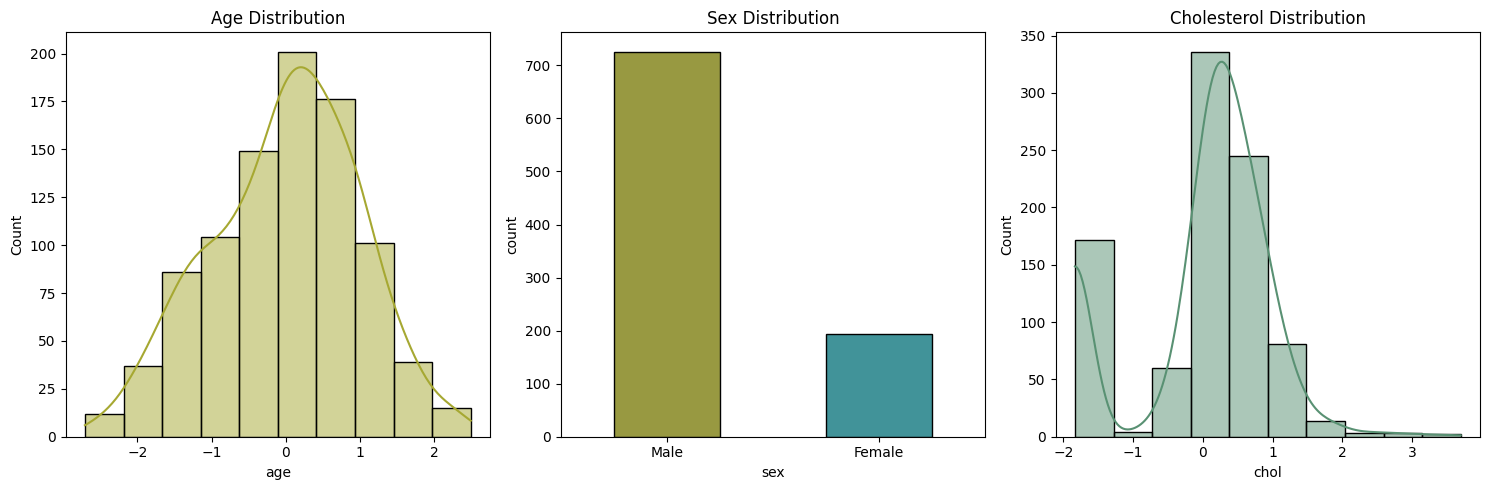

In [12]:
# Distribution of different features

custom_palette = ['#a6a832', '#32a0a8', '#599173', '#bfbf95']
plt.figure(figsize=(15,5))

#Distribution of Age
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True, bins=10, color='#a6a832',edgecolor='black')
plt.title('Age Distribution')

#Distribution of sex
plt.subplot(1, 3, 2)
sns.countplot(x='sex', data=df, palette=custom_palette, width=0.5,edgecolor='black')
plt.title('Sex Distribution')

#Distribution of Cholesterol
plt.subplot(1, 3, 3)
sns.histplot(df['chol'], kde=True, bins=10, color='#599173',edgecolor='black')
plt.title('Cholesterol Distribution')

plt.tight_layout()
plt.show()

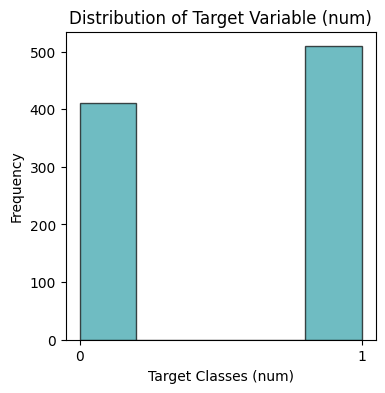

In [13]:
#Plotting the distribution of the target variable(num)

plt.figure(figsize=(4, 4))
plt.hist(df['num'], bins=5, color='#32a0a8', edgecolor='black', alpha=0.7)
plt.title('Distribution of Target Variable (num)')
plt.xlabel('Target Classes (num)')
plt.xticks(ticks=[0, 1])  
plt.ylabel('Frequency')
plt.show()

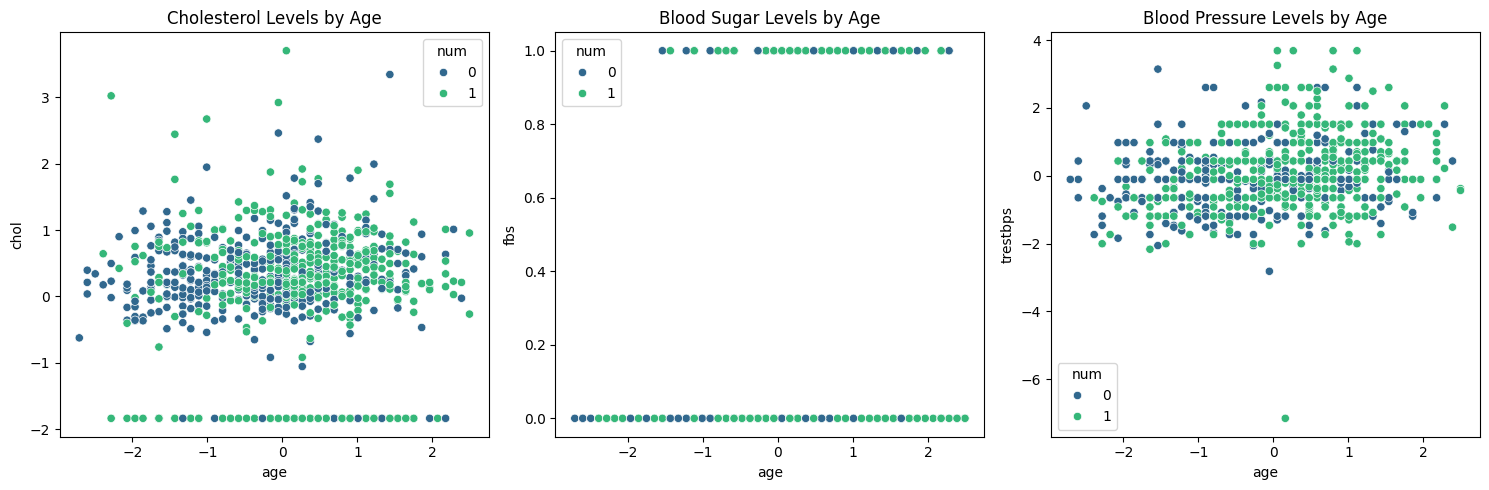

In [14]:
# Analysis between Age vs. Cholesterol, Blood Sugar, Blood Pressure

plt.figure(figsize=(15, 5))

#Age vs Cholesterol
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='chol', data=df,hue=df['num'], palette='viridis')
plt.title('Cholesterol Levels by Age')

#Age vs Blood Sugar
plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='fbs', data=df,hue=df['num'], palette='viridis')
plt.title('Blood Sugar Levels by Age')

#Age vs Blood Pressure
plt.subplot(1, 3, 3)
sns.scatterplot(x='age', y='trestbps', data=df,hue=df['num'], palette='viridis')
plt.title('Blood Pressure Levels by Age')
plt.tight_layout()
plt.show()

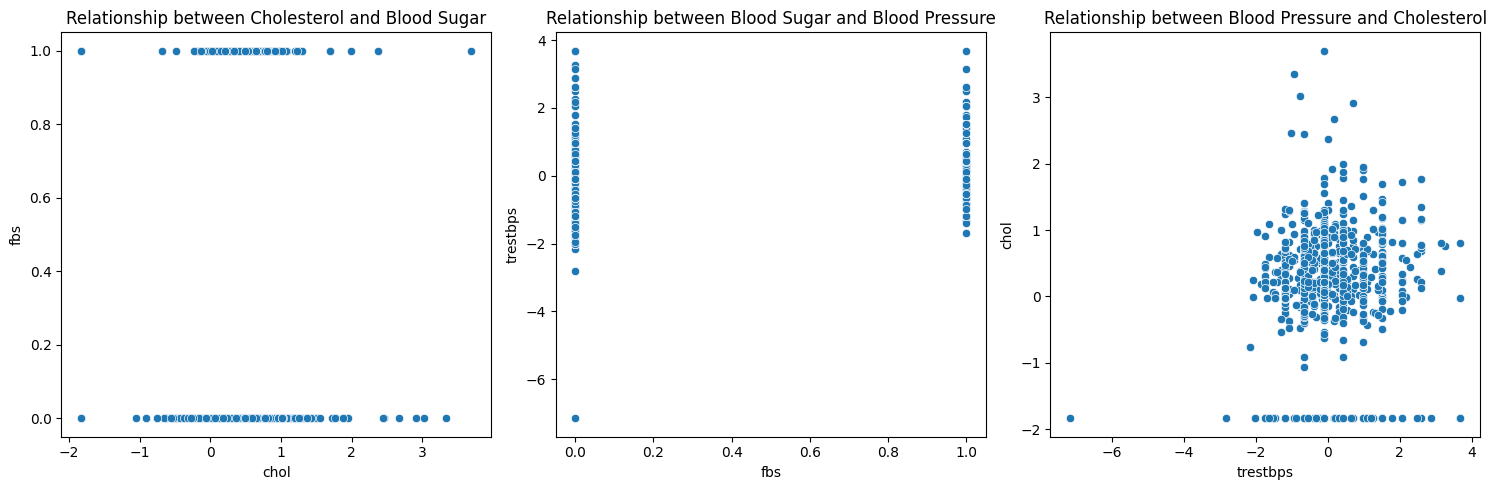

In [15]:
plt.figure(figsize=(15, 5))

# Releationship between cholesterol and sugar
plt.subplot(1,3,1)
sns.scatterplot(x='chol', y='fbs', data=df,)
plt.title('Relationship between Cholesterol and Blood Sugar')

# Relationship between sugar and blood pressure
plt.subplot(1,3,2)
sns.scatterplot(x='fbs', y='trestbps', data=df)
plt.title('Relationship between Blood Sugar and Blood Pressure')

# Relationship between blood pressure and cholesterol
plt.subplot(1,3,3)
sns.scatterplot(x='trestbps', y='chol', data=df)
plt.title('Relationship between Blood Pressure and Cholesterol')

plt.tight_layout()
plt.show()

# **C. Machine Learning**

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings(action="ignore")
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, accuracy_score

In [34]:
#Encoding Categorical Variables
label_encoder = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col]=le

In [35]:
# Defining features (X) and target (y)

X = df.drop('num', axis=1)
y = df['num']

In [36]:
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

# Automatically detect numerical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Apply one-hot encoding to categorical columns
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns in case train and test sets have different categories
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [37]:
# Standardize numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [38]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [29]:
# Logistic Regression with GridSearchCV
log_reg = LogisticRegression(max_iter=10000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy', verbose=2)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best Score:", grid_lr.best_score_)

# Predictions
y_pred_lr = grid_lr.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_lr))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...............C=0.01, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ................C=0.1, penalty=l2, solv

In [27]:
# Random Forest with GridSearchCV
rfc = RandomForestClassifier()

param_grid_rfc = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rfc = GridSearchCV(rfc, param_grid_rfc, cv=5, scoring='accuracy', verbose=2)
grid_rfc.fit(X_train, y_train)

print("Best Random Forest Parameters:", grid_rfc.best_params_)
print("Best Score:", grid_rfc.best_score_)

# Predictions
y_pred_rfc = grid_rfc.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_rfc))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END m

In [30]:
# Decision Tree with GridSearchCV
dtree = DecisionTreeClassifier()

param_grid_dtree = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dtree = GridSearchCV(dtree, param_grid_dtree, cv=5, scoring='accuracy', verbose=2)
grid_dtree.fit(X_train, y_train)

print("Best Decision Tree Parameters:", grid_dtree.best_params_)
print("Best Score:", grid_dtree.best_score_)

# Predictions
y_pred_dtree = grid_dtree.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_dtree))


Fitting 5 folds for each of 45 candidates, totalling 225 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[C